# **Part 4:** PEST++ Calibration Setup

**Authors:** Isabella Pedraza, Jack Logan <br>
**Last Updated:** May 5, 2025

### Agenda:
In this notebook, we will:
- Create a template directory to store model files and create PEST calibration files
- Write instruction, template, parameter, and control files for PEST++
- Go over the run procedure

In [1]:
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import psutil

import numpy as np
import re

import sys
import flopy
import flopy.mf6 as mf6

import pest_helpers as ph
import herebedragons as hbd

import subprocess

# Create Template Directory 

Now we can start to construct the PEST(++) interface by creating a template workspace. This will copy all the current model files into a new directory, along with an `org/` and `mult/` subdirectory. 

This can be done using the `create_pest_workspace()` helper function from `pest_helpers`. The documentation is below:

In [2]:
ph.create_temp_workspace?

Signature:
ph.create_temp_workspace(
    model_dir: str,
    template_dir: str,
    subdirs: list[str] = ['org', 'mult'],
)
Docstring:
Copy model directory and create subdirectories for PEST template workspace.

Parameters:
-----------
model_dir: str
    Absolute or relative path to top model workspace.
    Must hold all required files to run the model.

template_dir: str
    Absolute or relative path to top template workspace.
    Will copy *all* files and folder from `model_dir` and paste
    under `template_dir`

subdirs: list[str]
    Subdirectories to create in `template_dir`. Defaults to 
    'org' and 'mult'.
File:      c:\users\jackp\work\research\pfas\peterson-model\notebooks\pest_helpers.py
Type:      function

In [3]:
# folder containing original model files
model_dir = '../model/'

# specify a template directory (i.e. the PstFrom working folder)
template_dir = '../pest-template-new/'

ph.create_temp_workspace(model_dir, template_dir)  # Make temp dir

Workspace set up at: C:\Users\jackp\work\research\pfas\peterson-model\pest-template-new


## Sanitize model outputs

If you did not run this section at the bottom of notebook 3, run this cell to fix the MODFLOW 6 observational outputs. If you ran this at the bottom of notebook 3, continue to writing the INS file.

In [4]:
solutes = ['pfos', 'pfoa', 'pfhxs']

# Read CSV for each solute
for solute in solutes:
    ph.fix_scientific_notation(template_dir+f'outputs/{solute}_obs.csv')

# Write Output Instructional file

## Load in output and observational data

Using pandas, load in the observational and output CSVs. Align the times, convert into "long name" format.

In [5]:
# Read in output concentrations
output_conc = {
    solute: pd.read_csv(template_dir + f"outputs/{solute}_obs.csv")
    for solute in solutes
}

# Read in observed concentrations
observed_conc = {
    solute: pd.read_csv(template_dir + f"data/transport/{solute.upper()}-observations.csv")
    for solute in solutes
}

# Align observation times to model output times
observed_conc = {
    solute : ph.align_observed_to_output_times(observed_conc[solute], output_conc[solute]) 
    for solute in solutes
}

# Filter model outputs by non-null observed times
filtered_conc = {
    solute: output_conc[solute]
        .set_index('time')
        .where(observed_conc[solute].set_index('time').notna(), -999)
    for solute in solutes
}

# Convert to long format
obs_long = {
    solute: df.stack().reset_index().rename(columns={0: 'value', 'level_1': 'well'})
    for solute, df in filtered_conc.items()
}

obs_long['pfos'].head()

,time,well,value
0,59.0,BRD_6,-999.0
1,59.0,11960_OPR_2,-999.0
2,59.0,12425_OPR_1,-999.0
3,59.0,DLE,-999.0
4,59.0,GLD_3,-999.0


## Write INS file

In [6]:
for solute in solutes:
    ph.write_ins(obs_long[solute], template_dir + f'{solute}.csv.ins', solute)

[f for f in os.listdir(template_dir) if f.endswith(".ins")]

['pfhxs.csv.ins', 'pfoa.csv.ins', 'pfos.csv.ins']

### Write External INS .csv files to reference in PEST control file

In [7]:
ins_data = {
    'pest_file': ['pfos.csv.ins','pfoa.csv.ins','pfhxs.csv.ins'],
    'model_file': ['outputs/pfos_obs.csv','outputs/pfoa_obs.csv','outputs/pfhxs_obs.csv'],
}
ins_data = pd.DataFrame(ins_data)

ins_data.to_csv(template_dir + '/peterson_tran.insfile_data.csv', index=False)

### Write External observation .csv files to reference in PEST control file

In [8]:
ph.write_external_obs?

Signature:
ph.write_external_obs(
    df,
    path,
    solute,
    k=0.002,
    forecast_val=-888,
    nan_val=-999,
)
Docstring:
Write observational file with weights.

Parameters:
-----------
df: pd.DataFrame
    Long name dataframe

k: float | int
    obs weight scalar

path: str
    path to obs file

forecast_val: int | float
    If this value is read, will create an observation with weight 0.
    Allows compatibility with the forecasting functionality

nan_val: int | float
    If this value is read, no observation is created
File:      c:\users\jackp\work\research\pfas\peterson-model\notebooks\pest_helpers.py
Type:      function

In [9]:
for solute in solutes:
    ph.write_external_obs(obs_long[solute], template_dir + f"peterson_{solute}.obs_data.csv", solute)

# Write Input Template files

We are using a zone based calibration. This adjusts model parameters by zone numbers, with each zone given a range of possible values. The template files tells PEST(++) where the zones are in our model domain for each parameter. 

The zone-based transport parameters we are going to calibrate are:
- $k_D$ : Distance Coefficent
- $\theta$ : Porosity
- $\theta_{IM}$ : Immobile porosity
- $\rho_b$ : Bulk density

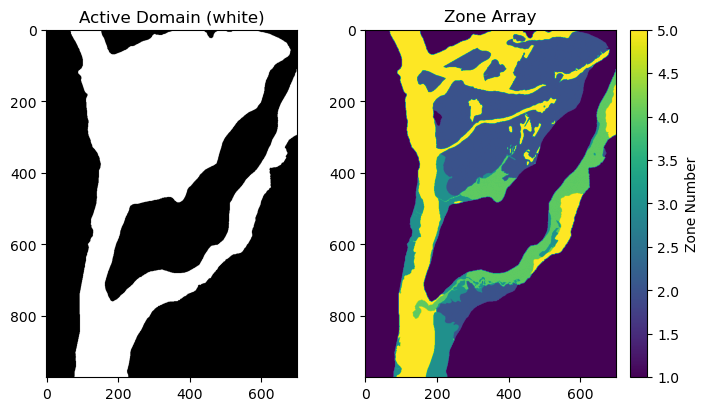

In [10]:
zones_matrix = np.loadtxt('../model/data/pest/zones.dat') # Load in zones matrix
ib = np.loadtxt('../model/data/domain/idomain.dat') # get the IDOMAIN array

fig, axs = plt.subplots(1, 2, figsize=(7,4), layout='constrained')
ax1, ax2 = axs

ax1.imshow(ib, cmap='Greys_r')
ax1.set_title('Active Domain (white)')

cs2 = ax2.imshow(zones_matrix)
fig.colorbar(cs2, ax=ax2, label='Zone Number')
ax2.set_title('Zone Array')

plt.show()

## Kd TPL

Need one TPL for each solute, all the others are a single tpl file

In [11]:
# kd for each solute
for solute in solutes:
    ph.write_tpl(template_dir + f'data/transport/kd-{solute}.dat.tpl', zones_matrix, 'kd', solute)

# porosity (THETA)
ph.write_tpl(template_dir + f'data/transport/porosity.dat.tpl', zones_matrix, 'theta', 'all')

# Immobile porosity (THETAIM)
ph.write_tpl(template_dir + f'data/transport/immobile-porosity.dat.tpl', zones_matrix, 'thetaim', 'all')

# bulk density (RHOB)
ph.write_tpl(template_dir + f'data/transport/bulk-density.dat.tpl', zones_matrix, 'rhob', 'all')

## CNC multiplier

- [ ] Work on this jawn

Thoughts: Replace the mult value based on the bound name

We want to calibrate the input concentrations using a multiplier. We have 4 separate source zones, each with a unique name. When we made the CNC file in notebook 02, we passed a "boundname" to each cell. We can leverage this boundname parameter to replace the default multiplier with a tag that will allow PEST(++) to calibrate the value.

In [12]:
# Example usage
cnc_pfos = '../pest-template/inputs/peterson_pfos.cnc'

tpl_cnc_pfos= '../pest-template/inputs/peterson_pfos.cnc.tpl'

# Make a map of zone to mult number
zone_map = {
    'AFFF':'~MULT1~',     # AFFF training zone
    'FS1' :'~MULT2~',      # Fire station 1
    'Golf':'~MULT3~',     # Golf course
    'FS2' :'~MULT4~',      # Fire Station 2
}

for solute in solutes:
    cnc_path = f"../pest-template/inputs/peterson_{solute}.cnc"
    tpl_path = cnc_path + '.tpl'
    ph.write_cnc_tpl(cnc_path, tpl_path, zone_map)

[f for f in os.listdir('../pest-template/inputs') if f.endswith(".tpl")]

['peterson_pfhxs.cnc.tpl', 'peterson_pfoa.cnc.tpl', 'peterson_pfos.cnc.tpl']

### Write External TPL .csv files to reference in PEST control file

In [13]:
# Get all .tpl files in data directory
data_files = [f"data/{f}" for f in os.listdir('../pest-template/data/transport/') if f.endswith(".tpl")]

# Get all .tpl files in the inputs directory
main_files = [f'inputs/{f}' for f in os.listdir('../pest-template/inputs/') if f.endswith(".tpl")]

#combine into one list
tpl_files = data_files + main_files

#get all corresponding model files
model_files = [f.replace('.tpl', '') for f in tpl_files]

In [14]:
tpl_data = pd.DataFrame({
    'pest_file': tpl_files,
    'model_file': model_files
})

tpl_data

,pest_file,model_file
0,data/bulk-density.dat.tpl,data/bulk-density.dat
1,data/immobile-porosity.dat.tpl,data/immobile-porosity.dat
2,data/kd-pfhxs.dat.tpl,data/kd-pfhxs.dat
3,data/kd-pfoa.dat.tpl,data/kd-pfoa.dat
4,data/kd-pfos.dat.tpl,data/kd-pfos.dat
5,data/porosity.dat.tpl,data/porosity.dat
6,inputs/peterson_pfhxs.cnc.tpl,inputs/peterson_pfhxs.cnc
7,inputs/peterson_pfoa.cnc.tpl,inputs/peterson_pfoa.cnc
8,inputs/peterson_pfos.cnc.tpl,inputs/peterson_pfos.cnc


In [15]:
tpl_data.to_csv('../pest-template/peterson_tran.tplfile_data.csv', index=False)

# Write Parameter files

In [16]:
def build_param_group_df(param_groups, defaults):
    """
    Build a DataFrame where each row corresponds to a parameter group with default values.

    Parameters:
    -----------
    param_groups: 
        List of parameter group names
    defaults: 
        Dictionary with column names and the value to assign per group

    Returns:
    - DataFrame with one row per parameter group
    """
    data = []
    for group in param_groups:
        row = {'pargpnme': group}
        row.update({key: val[0] for key, val in defaults.items()})
        data.append(row)

    return pd.DataFrame(data)

In [17]:
# Parameter groups
param_groups = ['porosity', 'immobile-porosity', 'bulk-density', 'conc']

# Shared default values
defaults = {
    'inctyp': ['relative'],
    'derinc': [0.01],
    'derinclb': [0],
    'forcen': ['switch'],
    'derincmul': [2],
    'dermthd': ['parabolic'],
    'splitthresh': [0.00001],
    'splitaction': [0.5],
    'n': ['smaller']
}

# Build the DataFrame
pargp_df = build_param_group_df(param_groups, defaults)
pargp_df

,pargpnme,inctyp,derinc,derinclb,forcen,derincmul,dermthd,splitthresh,splitaction,n
0,porosity,relative,0.01,0,switch,2,parabolic,0.00001,0.5,smaller
1,immobile-porosity,relative,0.01,0,switch,2,parabolic,0.00001,0.5,smaller
2,bulk-density,relative,0.01,0,switch,2,parabolic,0.00001,0.5,smaller
3,conc,relative,0.01,0,switch,2,parabolic,0.00001,0.5,smaller


In [18]:
# Save the DataFrame to a CSV file
output_filename = '../pest-template/peterson_tran.pargp_data.csv'
pargp_df.to_csv(output_filename, index=False)

## Build the parameter file for PEST++

In [19]:
# Define parameter metadata in a concise structure
parameter_definitions = {
    'MULT': {
        'group': 'conc',
        'count': 4,
        'lb': [1e-7],
        'ub': [1000],
        'init': [0.0276, 0.0180, 0.0039, 0.2001],
        'scale': [1]
    },
    'THETA': {
        'group': 'porosity',
        'count': 5,
        'lb': [0.005],
        'ub': [0.5],
        'init': [0.0873818, 0.29, 0.32, 0.22, 0.28],
        'scale': [1]
    },
    'THETAIM': {
        'group': 'immobile-porosity',
        'count': 5,
        'lb': [0.0005],
        'ub': [0.5],
        'init': [0.0867503, 0.085, 0.48, 0.12, 0.042],
        'scale': [1e-4]
    },
    'RHOB': {
        'group': 'bulk-density',
        'count': 5,
        'lb': [1300],
        'ub': [2500],
        'init': [2490.42, 1735, 1871, 1659, 2211],
        'scale': [1e-4]
    },
    'PFOS_KD': {
        'group': 'pfos_kd',
        'count': 5,
        'lb': [10**-8],
        'ub': [10**-1.3],
        'init': [2.754e-06, 10**(-5.4), 10**(-4.6), 10**(-4.9), 10**(-4.9)],
        'scale': [1e4]
    },
    'PFOA_KD': {
        'group': 'pfoa_kd',
        'count': 5,
        'lb': [10**-8],
        'ub': [10**-1.8],
        'init': [1.148e-06, 10**(-6.1), 10**(-4.9), 10**(-5.2), 10**(-5.2)],
        'scale': [1e4]
    },
    'PFHXS_KD': {
        'group': 'pfhxs_kd',
        'count': 5,
        'lb': [10**-8],
        'ub': [10**-2.2],
        'init': [6.026e-07, 10**(-6.2), 10**(-5.5), 10**(-5.2), 10**(-5.2)],
        'scale': [1e4]
    }
}

# Prepare lists to collect values
param_names, parval1, parlbnd, parubnd, pargp, scale = [], [], [], [], [], []

# Construct values from the metadata
for param, config in parameter_definitions.items():
    for i in range(config['count']):
        param_names.append(f"{param}{i+1}")
        parval1.append(config['init'][i])
        parlbnd.append(config['lb'][0])
        parubnd.append(config['ub'][0])
        pargp.append(config['group'])
        scale.append(config['scale'][0])

# Static parameter values
partrans = ['log'] * len(param_names)
parchglim = ['factor'] * len(param_names)
offset = [0] * len(param_names)
dercom = [1] * len(param_names)

# Define columns and construct the DataFrame
param_df = pd.DataFrame({
    'parnme': param_names,
    'partrans': partrans,
    'parchglim': parchglim,
    'parval1': parval1,
    'parlbnd': parlbnd,
    'parubnd': parubnd,
    'pargp': pargp,
    'scale': scale,
    'offset': offset,
    'dercom': dercom
})

param_df.to_csv('../pest-template/peterson_tran.par_data.csv', index=False)

# Write the Control File

In [21]:
ph.write_control_file(
    file_path=template_dir + "/peterson_tran.pst",
    parameter_group_file="peterson_tran.pargp_data.csv",
    parameter_file="peterson_tran.par_data.csv",
    obs_files=[
        "peterson_pfos.obs_data.csv",
        "peterson_pfoa.obs_data.csv",
        "peterson_pfhxs.obs_data.csv"
    ],
    model_command="python forward_run_tran.py",
    input_file="peterson_tran.tplfile_data.csv",
    output_file="peterson_tran.insfile_data.csv"
)

In [63]:
shutil.copy('../build_prior/peterson_tran.cov', template_ws)

'..\\peterson_template_tran\\peterson_tran.cov'

In [64]:
shutil.copy('forward_run_tran.py', template_ws)

'..\\peterson_template_tran\\forward_run_tran.py'

# Running PEST

**IF RUNNING ON HPC, STOP HERE**

Please please please don't run locally. It's huge.

In [102]:
shutil.copy('../bin/mf6.exe', template_ws)

'..\\peterson_template_tran\\mf6.exe'

In [103]:
shutil.copy('../bin/pestpp-glm.exe', template_ws)

'..\\peterson_template_tran\\pestpp-glm.exe'

In [104]:
shutil.copy('../bin/pestpp-ies.exe', template_ws)

'..\\peterson_template_tran\\pestpp-ies.exe'

In [112]:
pyemu.os_utils.run('pestpp-glm peterson_tran.pst', cwd=template_ws)

pestpp-glm.exe peterson_tran.pst


Exception: run() returned non-zero: 1